### Spearman Rank Correlation and Kendall Tau Correlation

In [1]:
# Deterministic domain and grid generators
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import statistics
import scipy.stats as stats

# Apply clean visualization style
plt.style.use('seaborn-v0_8_whitegrid' if 'seaborn-v0_8_whitegrid' in plt.style.available else 'default')
# print(plt.style.available)
# seaborn-v0_8_whitegrid : lA clean white grid style inspired by seaborn's whitegrid theme.
plt.rcParams["figure.dpi"] = 100
# rc = runtime configuration

## 1.Spearman Rank Correlation Coefficienr(p)

rank_x:  [1. 3. 2. 4.]
rank_y:  [1. 3. 2. 4.]
p_val:    0.0
Plain Python Spearman r: 1.0000
Scipy Spearman r:        1.0000
Pandas Spearman r:       1.0000


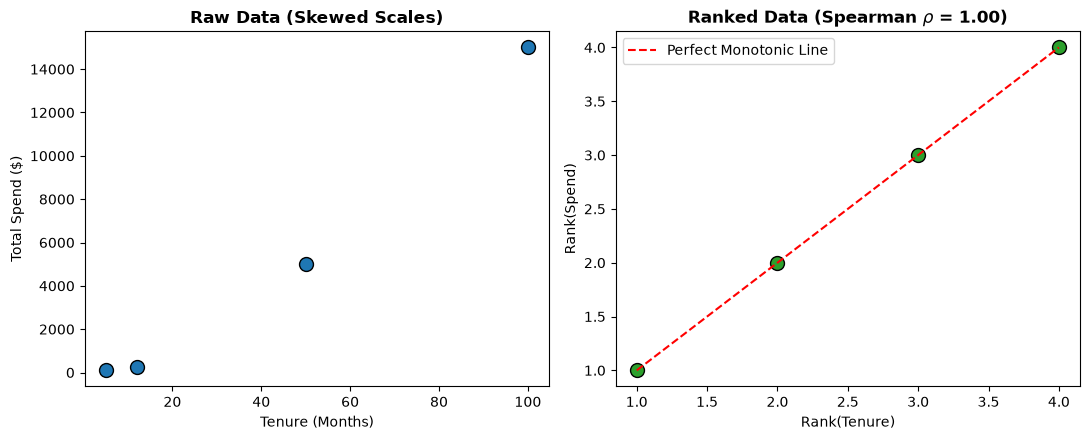

In [6]:
#  --- 1. Data Preparations ---
x_tenure = np.array([5, 50, 12, 100])
y_spend = np.array([100, 5000, 250, 15000])
n = len(x_tenure)
# 2. Plain python Implementations
rank_x = pd.Series(x_tenure).rank().values
print("rank_x: ", rank_x)
rank_y = pd.Series(y_spend).rank().values
print("rank_y: ", rank_y)

d = rank_x - rank_y
sum_d2 = sum(d ** 2)
spearman_python = 1 - (6 * sum_d2) / (n * (n**2 - 1))

# --- 3. SCIPY & PANDAS IMPLEMENTATIONS ---
spearman_scipy, p_val = stats.spearmanr(x_tenure, y_spend)
spearman_pandas = pd.Series(x_tenure).corr(pd.Series(y_spend), method='spearman')
print(f"p_val:    {p_val}")
print(f"Plain Python Spearman r: {spearman_python:.4f}")
print(f"Scipy Spearman r:        {spearman_scipy:.4f}")
print(f"Pandas Spearman r:       {spearman_pandas:.4f}")

# --- 4. VISUAL REPRESENTATION ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# Raw Values Scatter Plot
ax1.scatter(x_tenure, y_spend, color='#1f77b4', s=100, edgecolors='k')
ax1.set_title('Raw Data (Skewed Scales)', fontweight='bold')
ax1.set_xlabel('Tenure (Months)')
ax1.set_ylabel('Total Spend ($)')

# Ranked Values Scatter Plot
ax2.scatter(rank_x, rank_y, color='#2ca02c', s=100, edgecolors='k')
ax2.plot([1, 4], [1, 4], color='red', linestyle='--', label='Perfect Monotonic Line')
ax2.set_title(f'Ranked Data (Spearman $\\rho$ = {spearman_scipy:.2f})', fontweight='bold')
ax2.set_xlabel('Rank(Tenure)')
ax2.set_ylabel('Rank(Spend)')
ax2.legend()

plt.tight_layout()
plt.show()

## 2. Kendall Tau Correlation Coefficient (𝜏)

Plain Python Kendall Tau: 0.6667
SciPy stats.kendalltau:  0.6667 (p-value: 0.3333)
Pandas Series corr:       0.6667



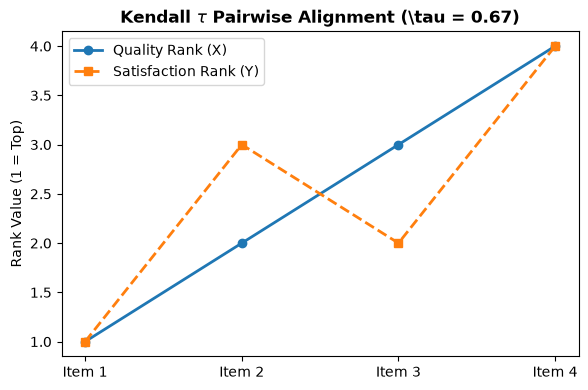

In [8]:
# --- 1. DATA PREPARATION ---
x_rank = np.array([1, 2, 3, 4])
y_rank = np.array([1, 3, 2, 4])
n = len(x_rank)

# --- 2. PLAIN PYTHON IMPLEMENTATION ---
concordant = 0
discordant = 0

for i in range(n):
    for j in range(i+1,n):
        dx = x_rank[i] - x_rank[j]
        dy = rank_y[i] - rank_y[j]
        prod = dx * dy
        if prod > 0:
            concordant += 1
        else:
            discordant += 1
            
total_pairs = (n * (n - 1)) // 2
kendall_python = (concordant - discordant) / total_pairs


# --- 3. SCIPY & PANDAS IMPLEMENTATIONS ---
kendall_scipy, p_val_k = stats.kendalltau(x_rank, y_rank)
kendall_pandas = pd.Series(x_rank).corr(pd.Series(y_rank), method='kendall')

print(f"Plain Python Kendall Tau: {kendall_python:.4f}")
print(f"SciPy stats.kendalltau:  {kendall_scipy:.4f} (p-value: {p_val_k:.4f})")
print(f"Pandas Series corr:       {kendall_pandas:.4f}\n")

# --- 4. VISUAL REPRESENTATION ---
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, n+1), x_rank, marker='o', label='Quality Rank (X)', linewidth=2, color='#1f77b4')
ax.plot(range(1, n+1), y_rank, marker='s', label='Satisfaction Rank (Y)', linewidth=2, linestyle='--', color='#ff7f0e')

ax.set_xticks(range(1, n+1))
ax.set_xticklabels([f'Item {i}' for i in range(1, n+1)])
ax.set_ylabel('Rank Value (1 = Top)')
ax.set_title(f'Kendall $\\tau$ Pairwise Alignment (\\tau = {kendall_scipy:.2f})', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Pearson vs. Spearman vs. Kendall: Outlier Robustness

=== CLEAN DATA metrics ===
Pearson r:  0.9989 | Spearman r_s: 1.0000 | Kendall tau: 1.0000

=== OUTLIER CORRUPTED DATA metrics ===
Pearson r:  -0.3900 (Severely flipped negative!)
Spearman r_s: 0.4545 (Remains robust)
Kendall tau:  0.6000 (Remains robust)



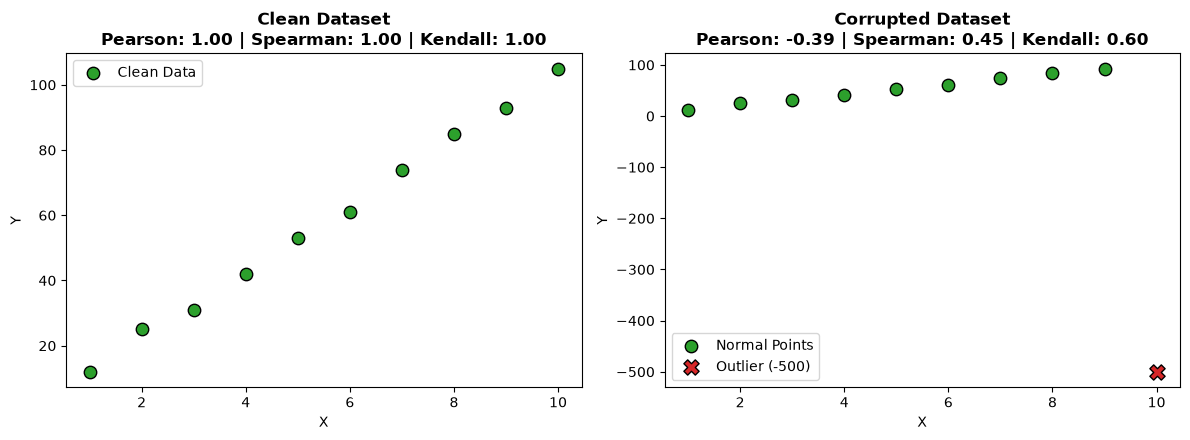

In [11]:
# --- 1. DATASET GENERATION WITH OUTLIER ---
x_clean = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y_clean = np.array([12, 25, 31, 42, 53, 61, 74, 85, 93, 105])

# Inject a severe measurement error outlier
x_outlier = x_clean.copy()
y_outlier = y_clean.copy()
y_outlier[-1] = -500  # Extreme anomaly

# Compute correlations for Clean Data
p_clean = np.corrcoef(x_clean, y_clean)[0, 1]
s_clean, _ = stats.spearmanr(x_clean, y_clean)
k_clean, _ = stats.kendalltau(x_clean, y_clean)

# Compute correlations for Outlier Data
p_outlier = np.corrcoef(x_outlier, y_outlier)[0, 1]
s_outlier, _ = stats.spearmanr(x_outlier, y_outlier)
k_outlier, _ = stats.kendalltau(x_outlier, y_outlier)

print("=== CLEAN DATA metrics ===")
print(f"Pearson r:  {p_clean:.4f} | Spearman r_s: {s_clean:.4f} | Kendall tau: {k_clean:.4f}")
print("\n=== OUTLIER CORRUPTED DATA metrics ===")
print(f"Pearson r:  {p_outlier:.4f} (Severely flipped negative!)")
print(f"Spearman r_s: {s_outlier:.4f} (Remains robust)")
print(f"Kendall tau:  {k_outlier:.4f} (Remains robust)\n")

# --- 2. MULTI-PANEL VISUALIZATION ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot Clean Data
ax1.scatter(x_clean, y_clean, color='#2ca02c', s=80, edgecolors='k', label='Clean Data')
ax1.set_title(f'Clean Dataset\nPearson: {p_clean:.2f} | Spearman: {s_clean:.2f} | Kendall: {k_clean:.2f}', fontweight='bold')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.legend()

# Plot Outlier Data
ax2.scatter(x_outlier[:-1], y_outlier[:-1], color='#2ca02c', s=80, edgecolors='k', label='Normal Points')
ax2.scatter(x_outlier[-1], y_outlier[-1], color='#d62728', s=120, edgecolors='k', marker='X', label='Outlier (-500)')
ax2.set_title(f'Corrupted Dataset\nPearson: {p_outlier:.2f} | Spearman: {s_outlier:.2f} | Kendall: {k_outlier:.2f}', fontweight='bold')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.legend()

plt.tight_layout()
plt.show()